# Neuron Subset Ablation

Plot SigLIP cosine similarity and 2-AFC accuracy vs. number of input neurons for the global and obj-crop multihead models trained with category conditioning.

Each data point is the mean ± std across 5 random neuron subset seeds.

In [4]:
import re
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

In [5]:
METRICS = ['val_cos_siglip', 'val_2afc_siglip']
NN_RE = re.compile(r'_nn(\d+)_ns(\d+)')


def load_ablation_results(ckpt_subdir: str) -> dict:
    """Scan a checkpoint subdirectory for neuron-ablation runs.

    Returns {n_neurons: {metric: [val_seed0, ...]}}。
    'full' key = runs without a subset suffix.
    """
    base = CHECKPOINT_DIR / 'multihead' / ckpt_subdir
    if not base.exists():
        return {}
    results: dict = {}

    for run_dir in sorted(base.iterdir()):
        if not run_dir.is_dir():
            continue
        best_pt = run_dir / 'best.pt'
        if not best_pt.exists():
            continue

        m = NN_RE.search(run_dir.name)
        n_neurons = int(m.group(1)) if m else 'full'

        ckpt = torch.load(best_pt, weights_only=False, map_location='cpu')
        metrics = ckpt.get('metrics', {})
        test_metrics = ckpt.get('test_metrics', {})

        if n_neurons not in results:
            results[n_neurons] = {k: [] for k in METRICS}
        for metric in METRICS:
            val = metrics.get(metric, test_metrics.get(metric))
            if val is not None:
                results[n_neurons][metric].append(val)

    return results


MODELS = [
    ('hvm',     'Global',   'steelblue'),
    ('hvm_obj', 'Obj-crop', 'darkorange'),
]

all_results = {subdir: load_ablation_results(subdir) for subdir, *_ in MODELS}

for subdir, label, _ in MODELS:
    r = all_results[subdir]
    print(f"{label:20s}: {dict((k, len(v['val_cos_siglip'])) for k, v in r.items())}")

Global              : {'full': 1, 1000: 5, 100: 5, 1500: 5, 2000: 5, 250: 5, 500: 5, 750: 5}
Obj-crop            : {'full': 1, 1000: 5, 100: 5, 1500: 5, 2000: 5, 250: 5, 500: 5, 750: 5}


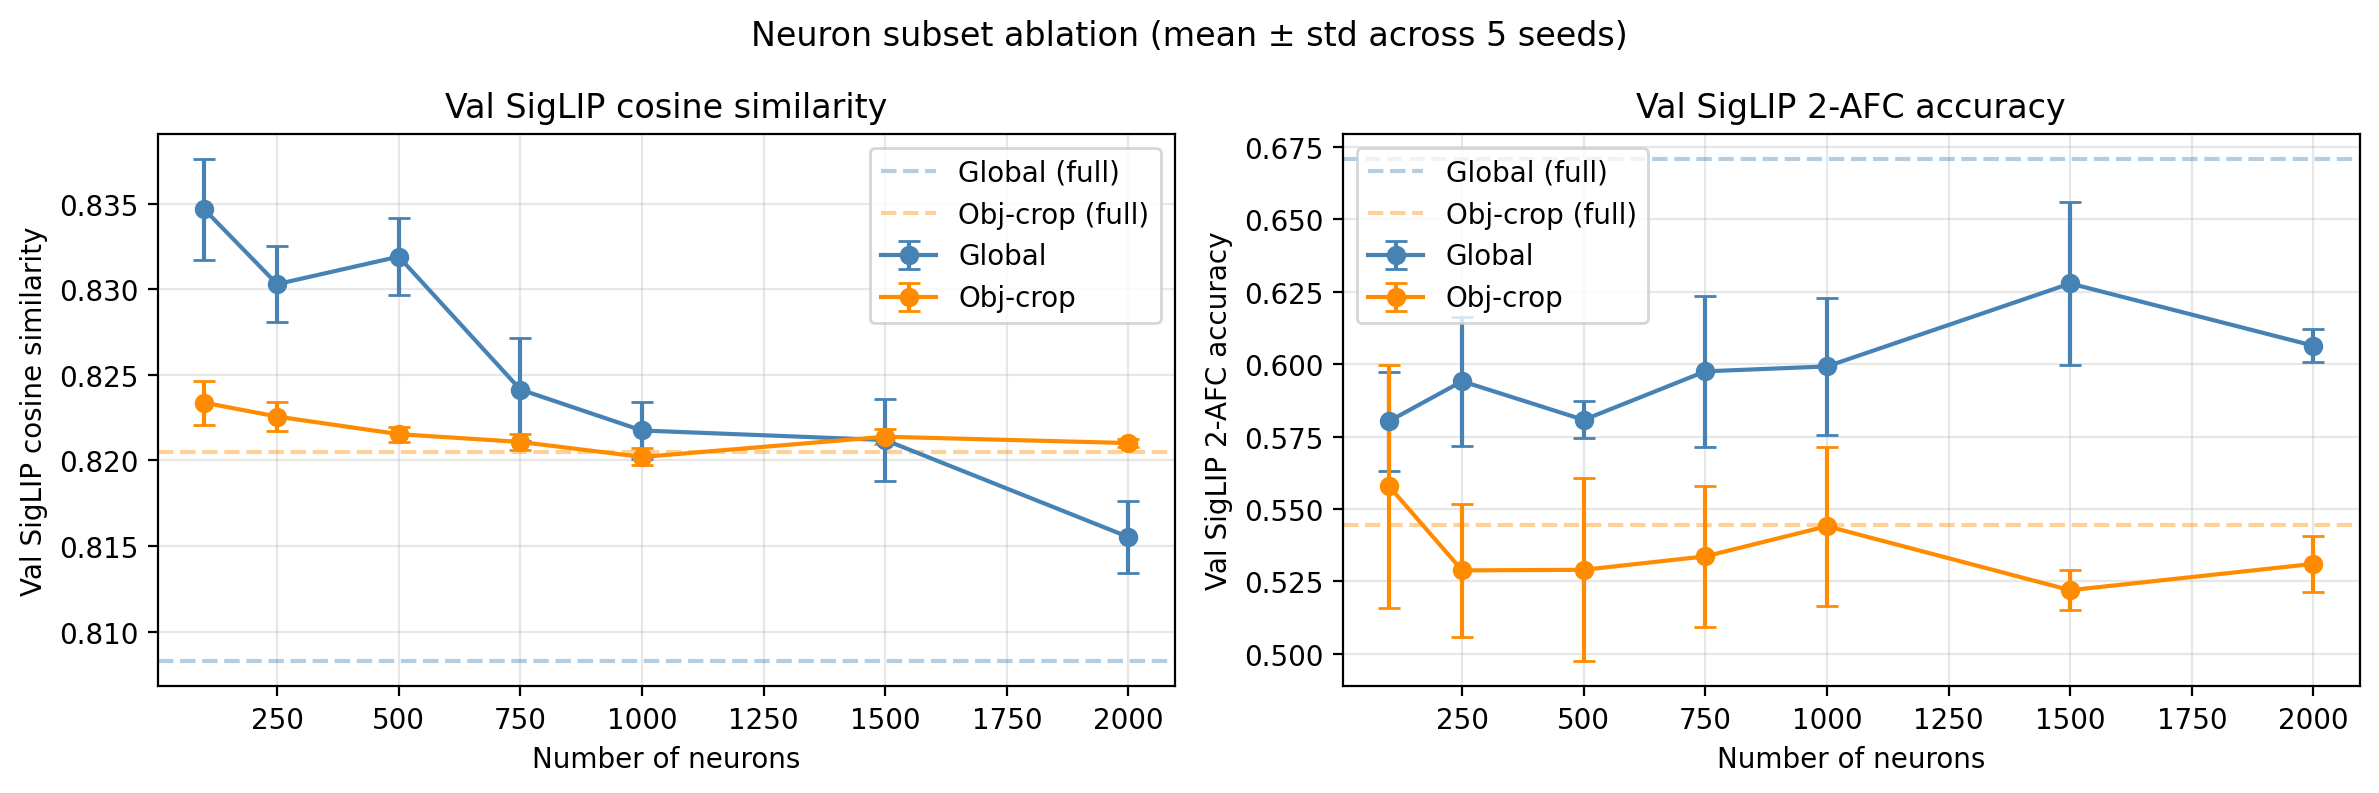

In [6]:
def plot_ablation(results: dict, label: str, ax: plt.Axes, metric: str, color: str):
    xs, means, stds = [], [], []
    for n in sorted(k for k in results if k != 'full'):
        vals = results[n][metric]
        if vals:
            xs.append(n)
            means.append(np.mean(vals))
            stds.append(np.std(vals))

    full_vals = results.get('full', {}).get(metric, [])

    ax.errorbar(xs, means, yerr=stds, fmt='o-', color=color, capsize=4, label=label)
    if full_vals:
        ax.axhline(np.mean(full_vals), color=color, linestyle='--', alpha=0.4,
                   label=f'{label} (full)')


metric_labels = {
    'val_cos_siglip':  'Val SigLIP cosine similarity',
    'val_2afc_siglip': 'Val SigLIP 2-AFC accuracy',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, METRICS):
    for subdir, label, color in MODELS:
        r = all_results[subdir]
        if r:
            plot_ablation(r, label, ax, metric, color=color)
    ax.set_xlabel('Number of neurons')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(metric_labels[metric])
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Neuron subset ablation (mean ± std across 5 seeds)', fontsize=12)
fig.tight_layout()
plt.savefig('outputs/neuron_ablation.pdf', bbox_inches='tight')
plt.show()